In [1]:
dataset_name = "1919_SYN_300"

In [2]:
import os
import json
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    accuracy_score,
    f1_score,
    classification_report,
)
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

In [3]:
dataset = dataset_name  
train_dir = f"DS_REAL_SPLITED_{dataset}"
imgsz = 64
epochs = 300
project = "ResNet152-RESULTS"
run_name = dataset

# Pastas esperadas
root = Path(train_dir)
train_root = root / "train"
val_root = root / "val"
test_root = root / "test"

# Saída
out_dir = Path(project) / run_name
weights_dir = out_dir / "weights"
weights_dir.mkdir(parents=True, exist_ok=True)
best_path = weights_dir / "best.pt"
meta_path = out_dir / "meta.json"


# =========================
# Utilitários
# =========================
def set_seed(seed: int = 42) -> None:
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def get_device() -> torch.device:
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


transform = transforms.Compose([
    transforms.Resize((imgsz, imgsz)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

def build_model(num_classes: int) -> nn.Module:
    model = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V2)
    in_feats = model.fc.in_features
    model.fc = nn.Linear(in_feats, num_classes)
    return model

@torch.no_grad()
def evaluate_on_loader(model: nn.Module, loader: DataLoader, device: torch.device):
    model.eval()
    y_true, y_pred = [], []
    total_loss = 0.0
    criterion = nn.CrossEntropyLoss()

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)
        total_loss += float(loss.item()) * x.size(0)

        pred = torch.argmax(logits, dim=1)
        y_true.append(y.detach().cpu().numpy())
        y_pred.append(pred.detach().cpu().numpy())

    y_true = np.concatenate(y_true) if y_true else np.array([], dtype=np.int64)
    y_pred = np.concatenate(y_pred) if y_pred else np.array([], dtype=np.int64)
    avg_loss = total_loss / max(len(loader.dataset), 1)
    return y_true, y_pred, avg_loss

def avaliar_modelo_resnet(model: nn.Module, val_path: str, imgsz: int = 64, verbose: bool = False):
    """
    Mantém a mesma assinatura/ideia do seu avaliar_modelo:
    - varre subpastas por classe
    - faz top-1
    - imprime acurácia + classification_report
    """
    device = next(model.parameters()).device
    val_path = Path(val_path)

    class_names = sorted([d.name for d in val_path.iterdir() if d.is_dir()])
    class_to_idx = {cls_name: idx for idx, cls_name in enumerate(class_names)}

    tfm = transforms.Compose([
        transforms.Resize((imgsz, imgsz)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

    y_true, y_pred = [], []

    model.eval()
    with torch.no_grad():
        for cls_name in class_names:
            cls_dir = val_path / cls_name
            label = class_to_idx[cls_name]

            for img_path in cls_dir.glob("*.*"):
                try:
                    img = Image.open(img_path).convert("RGB")
                    x = tfm(img).unsqueeze(0).to(device)
                    logits = model(x)
                    pred = int(torch.argmax(logits, dim=1).item())

                    y_true.append(label)
                    y_pred.append(pred)

                    if verbose:
                        print(f"Imagem: {img_path.name} | Real: {cls_name} | Previsto: {class_names[pred]}")
                except Exception as e:
                    print(f"[ERRO] Falha ao processar {img_path.name}: {e}")

    y_true = np.array(y_true, dtype=np.int64)
    y_pred = np.array(y_pred, dtype=np.int64)

    acc = accuracy_score(y_true, y_pred) if len(y_true) else 0.0
    report = classification_report(y_true, y_pred, target_names=class_names, zero_division=0)

    print(f"\n🔍 Acurácia: {acc:.4f}")
    print(report)

    return y_true, y_pred, report

def plotar_metricas(y_true, y_pred):
    # Mesma função do seu script, preservando a lógica
    accuracy = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    metrics = [accuracy, precision, recall, f1]
    metrics_names = ["Acurácia", "Precisão", "Recall", "f1_score"]

    plt.figure(figsize=(8, 6))
    plt.bar(metrics_names, metrics, color=["blue", "green", "orange", "yellow"])
    plt.title("Acurácia, Precisão, Recall & F1")
    plt.ylim(0, 1)
    plt.ylabel("Valor")
    for i, value in enumerate(metrics):
        plt.text(i, value + 0.02, f"{value:.4f}", ha="center", va="bottom", fontsize=12)
    plt.show()

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=np.arange(1, cm.shape[1] + 1),
        yticklabels=np.arange(1, cm.shape[0] + 1),
    )
    plt.title("Matriz de Confusão")
    plt.xlabel("Predições")
    plt.ylabel("Verdadeiros")
    plt.show()

    print(f"Acurácia: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Confusion Matrix:\n{cm}")

In [4]:
# =========================
# Dataset / Dataloaders
# =========================
set_seed(42)
device = get_device()

if not train_root.exists():
    raise FileNotFoundError(f"Não achei {train_root}. Esperado: DS_REAL_SPLITED_<dataset>/train/...")

train_ds = datasets.ImageFolder(str(train_root), transform=transform)

# Se existir /val, usa como validação; senão, cria split 80/20 a partir do train
if val_root.exists():
    val_ds = datasets.ImageFolder(str(val_root), transform=transform)
else:
    n = len(train_ds)
    idx = np.arange(n)
    np.random.shuffle(idx)
    split = int(0.8 * n)
    train_idx, val_idx = idx[:split], idx[split:]
    val_ds = Subset(train_ds, val_idx)
    train_ds = Subset(train_ds, train_idx)

# Test sempre igual ao seu (usa /test)
if not test_root.exists():
    raise FileNotFoundError(f"Não achei {test_root}. Esperado: DS_REAL_SPLITED_<dataset>/test/...")
test_ds = datasets.ImageFolder(str(test_root), transform=transform)

num_classes = len(train_ds.dataset.classes) if isinstance(train_ds, Subset) else len(train_ds.classes)

# DataLoaders (defaults explícitos: batch_size=32, num_workers=2; ajuste se quiser)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

In [5]:
# =========================
# Treinamento
# =========================
model = build_model(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

best_val_loss = float("inf")

for ep in range(1, epochs + 1):
    model.train()
    running_loss = 0.0
    n_seen = 0

    for x, y in train_loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += float(loss.item()) * x.size(0)
        n_seen += x.size(0)

    scheduler.step()

    train_loss = running_loss / max(n_seen, 1)
    _, _, val_loss = evaluate_on_loader(model, val_loader, device)

    # Salva melhor (equivalente ao "best.pt")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "num_classes": num_classes,
                "imgsz": imgsz,
                "classes": (train_ds.dataset.classes if isinstance(train_ds, Subset) else train_ds.classes),
            },
            best_path,
        )

    if ep == 1 or ep % 10 == 0:
        print(f"[Epoch {ep:03d}/{epochs}] train_loss={train_loss:.6f} val_loss={val_loss:.6f} best_val_loss={best_val_loss:.6f}")

# Metadados simples do run
meta = {
    "dataset": dataset,
    "train_dir": str(root),
    "epochs": epochs,
    "imgsz": imgsz,
    "best_val_loss": best_val_loss,
    "weights": str(best_path),
}
meta_path.write_text(json.dumps(meta, ensure_ascii=False, indent=2), encoding="utf-8")

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth
100%|████████████████████████████████████████████████████████████████████████████████| 230M/230M [00:15<00:00, 15.4MB/s]
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/conv.py:459: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,


[Epoch 001/300] train_loss=1.428512 val_loss=1.064837 best_val_loss=1.064837
[Epoch 010/300] train_loss=0.137846 val_loss=1.207862 best_val_loss=1.045107
[Epoch 020/300] train_loss=0.026567 val_loss=1.420953 best_val_loss=1.045107
[Epoch 030/300] train_loss=0.048845 val_loss=1.561191 best_val_loss=1.045107
[Epoch 040/300] train_loss=0.054736 val_loss=1.508458 best_val_loss=1.045107
[Epoch 050/300] train_loss=0.055008 val_loss=1.439779 best_val_loss=1.045107
[Epoch 060/300] train_loss=0.044685 val_loss=2.025020 best_val_loss=1.045107
[Epoch 070/300] train_loss=0.000047 val_loss=2.264247 best_val_loss=1.045107
[Epoch 080/300] train_loss=0.000015 val_loss=3.550914 best_val_loss=1.045107
[Epoch 090/300] train_loss=0.000005 val_loss=2.642426 best_val_loss=1.045107
[Epoch 100/300] train_loss=0.000004 val_loss=2.996766 best_val_loss=1.045107
[Epoch 110/300] train_loss=0.000002 val_loss=2.944060 best_val_loss=1.045107
[Epoch 120/300] train_loss=0.000001 val_loss=3.145071 best_val_loss=1.045107

187


🔍 Acurácia: 0.6907
                   precision    recall  f1-score   support

      BULKCARRIER       0.71      0.39      0.50        75
    CONTAINERSHIP       0.64      0.75      0.69        75
     GENERALCARGO       0.61      0.64      0.62        75
OILPRODUCTSTANKER       0.40      0.55      0.46        75
   PASSENGERSSHIP       0.80      0.80      0.80        75
           TANKER       0.57      0.61      0.59        75
          TRAWLER       0.67      0.79      0.72        75
              TUG       0.86      0.85      0.86        75
  VEHICLESCARRIER       1.00      0.60      0.75        75
            YACHT       0.90      0.93      0.92        75

         accuracy                           0.69       750
        macro avg       0.72      0.69      0.69       750
     weighted avg       0.72      0.69      0.69       750



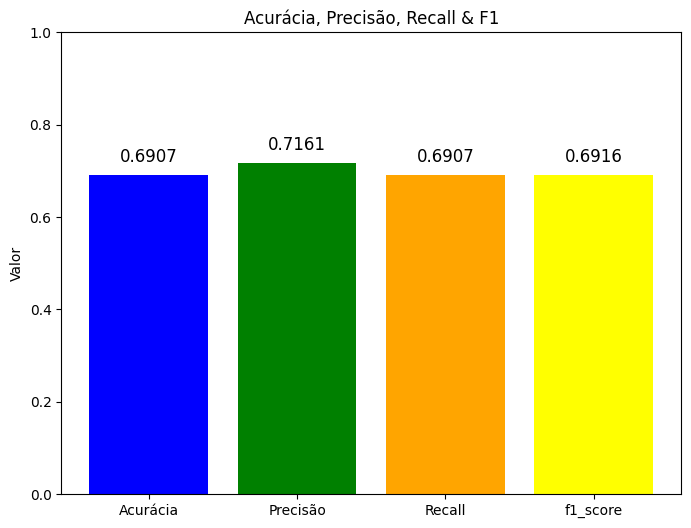

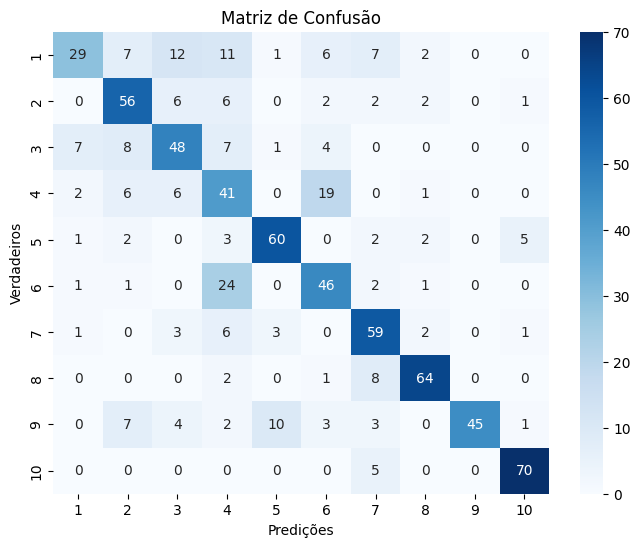

Acurácia: 0.6907
Precision: 0.7161
Recall: 0.6907
F1 Score: 0.6916
Confusion Matrix:
[[29  7 12 11  1  6  7  2  0  0]
 [ 0 56  6  6  0  2  2  2  0  1]
 [ 7  8 48  7  1  4  0  0  0  0]
 [ 2  6  6 41  0 19  0  1  0  0]
 [ 1  2  0  3 60  0  2  2  0  5]
 [ 1  1  0 24  0 46  2  1  0  0]
 [ 1  0  3  6  3  0 59  2  0  1]
 [ 0  0  0  2  0  1  8 64  0  0]
 [ 0  7  4  2 10  3  3  0 45  1]
 [ 0  0  0  0  0  0  5  0  0 70]]


In [6]:
# =========================
# Carregar best e avaliar no /test (igual ao seu)
# =========================
ckpt = torch.load(best_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

# Avaliação no /test com mesma lógica do seu avaliar_modelo (varrendo diretórios)
val_path = str(test_root)
y_true, y_pred, relatorio = avaliar_modelo_resnet(model, val_path, imgsz=imgsz, verbose=False)

# Plots (mesma função do seu script)
plotar_metricas(y_true, y_pred)